# Модель распространения рекламы

**Цель работы:** Исследовать динамику распространения информации о новом
салоне красоты с помощью дифференциального уравнения, учитывающего
платную рекламу и "сарафанное радио".

## 1. Теоретическое введение

Модель описывается уравнением:

$$ \frac{dn}{dt} = (\alpha_1(t) + \alpha_2(t) \cdot n(t)) \cdot (N - n(t)) $$

где:
- $n(t)$ — число людей, знающих о салоне в момент времени $t$
- $N$ — общее число потенциальных клиентов
- $\alpha_1(t)$ — интенсивность платной рекламы
- $\alpha_2(t)$ — интенсивность "сарафанного радио"

## 2. Параметры варианта №56

| Параметр | Значение | Описание |
|----------|----------|----------|
| $N$ | 1505 | Общее число потенциальных клиентов |
| $n_0$ | 7 | Начальное число знающих |
| $\alpha_1$ | 0.68 | Случай 1: платная реклама доминирует |
| $\alpha_2$ | 0.00009 | Случай 1 |
| $\alpha_1$ | 0.00001 | Случай 2: сарафанное радио доминирует |
| $\alpha_2$ | 0.28 | Случай 2 |

## 3. Инициализация проекта и загрузка пакетов

In [1]:
using DrWatson
@quickactivate "project"

using DifferentialEquations
using Plots
using LaTeXStrings

include(srcdir("advertising_params.jl"))
using .AdvertisingParams

script_name = splitext(basename(PROGRAM_FILE))[1]
mkpath(plotsdir(script_name))
mkpath(datadir(script_name))

println("="^60)
println("МОДЕЛЬ РАСПРОСТРАНЕНИЯ РЕКЛАМЫ")
println("Вариант №56")
println("="^60)
println("\nПараметры:")
println("  N = $N (общее число потенциальных клиентов)")
println("  n₀ = $n0 (начальное число знающих)")
println("  t ∈ [$(tspan[1]), $(tspan[2])] дней")
println("="^60)

МОДЕЛЬ РАСПРОСТРАНЕНИЯ РЕКЛАМЫ
Вариант №56

Параметры:
  N = 1505.0 (общее число потенциальных клиентов)
  n₀ = 7.0 (начальное число знающих)
  t ∈ [0.0, 30.0] дней


## 4. Случай 1: Платная реклама доминирует

Параметры: $\alpha_1 = 0.68$, $\alpha_2 = 0.00009$


1. СЛУЧАЙ 1: Платная реклама доминирует
   α₁ = 0.68, α₂ = 0.00009


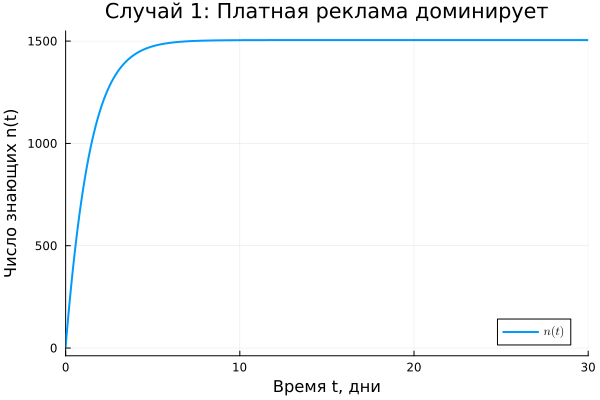

In [2]:
println("\n1. СЛУЧАЙ 1: Платная реклама доминирует")
println("   α₁ = 0.68, α₂ = 0.00009")

prob1 = ODEProblem(case1!, [n0], tspan)
sol1 = solve(prob1, saveat=0.1)

p1 = plot(sol1, idxs=1, label=L"n(t)", linewidth=2,
          xlabel="Время t, дни", ylabel="Число знающих n(t)",
          title="Случай 1: Платная реклама доминирует")

## 5. Случай 2: Сарафанное радио доминирует

Параметры: $\alpha_1 = 0.00001$, $\alpha_2 = 0.28$

In [3]:
println("\n2. СЛУЧАЙ 2: Сарафанное радио доминирует")
println("   α₁ = 0.00001, α₂ = 0.28")

prob2 = ODEProblem(case2!, [n0], tspan)
sol2 = solve(prob2, saveat=0.1)


2. СЛУЧАЙ 2: Сарафанное радио доминирует
   α₁ = 0.00001, α₂ = 0.28


retcode: Success
Interpolation: 1st order linear
t: 301-element Vector{Float64}:
  0.0
  0.1
  0.2
  0.3
  0.4
  0.5
  0.6
  0.7
  0.8
  0.9
  1.0
  1.1
  1.2
  ⋮
 28.9
 29.0
 29.1
 29.2
 29.3
 29.4
 29.5
 29.6
 29.7
 29.8
 29.9
 30.0
u: 301-element Vector{Vector{Float64}}:
 [7.0]
 [1504.5153161277594]
 [1505.0001113931978]
 [1505.0000063010277]
 [1504.9999681450608]
 [1504.9999752607464]
 [1504.9999989054359]
 [1504.999999337988]
 [1504.9999997272894]
 [1505.0000000733403]
 [1505.0000003761406]
 [1505.0000006356902]
 [1505.0000008519894]
 ⋮
 [1505.0000000000023]
 [1505.000000000002]
 [1505.000000000002]
 [1505.0000000000018]
 [1505.0000000000016]
 [1505.0000000000014]
 [1505.0000000000011]
 [1505.000000000001]
 [1505.0000000000007]
 [1505.0000000000005]
 [1505.0000000000002]
 [1504.9999999999998]

Получаем значения решения

In [4]:
t_vals = sol2.t
n_vals = [u[1] for u in sol2.u]

301-element Vector{Float64}:
    7.0
 1504.5153161277594
 1505.0001113931978
 1505.0000063010277
 1504.9999681450608
 1504.9999752607464
 1504.9999989054359
 1504.999999337988
 1504.9999997272894
 1505.0000000733403
 1505.0000003761406
 1505.0000006356902
 1505.0000008519894
    ⋮
 1505.0000000000023
 1505.000000000002
 1505.000000000002
 1505.0000000000018
 1505.0000000000016
 1505.0000000000014
 1505.0000000000011
 1505.000000000001
 1505.0000000000007
 1505.0000000000005
 1505.0000000000002
 1504.9999999999998

Вычисляем скорость

In [5]:
dn2 = zeros(length(t_vals))
for i in 1:length(t_vals)
    n = n_vals[i]
    α₁ = 0.00001
    α₂ = 0.28
    dn2[i] = (α₁ + α₂ * n) * (N - n)
end

Нахождение максимальной скорости

   📊 Максимальная скорость распространения:
      t_max = 0.0 дней
      v_max = 2936.09 чел/день


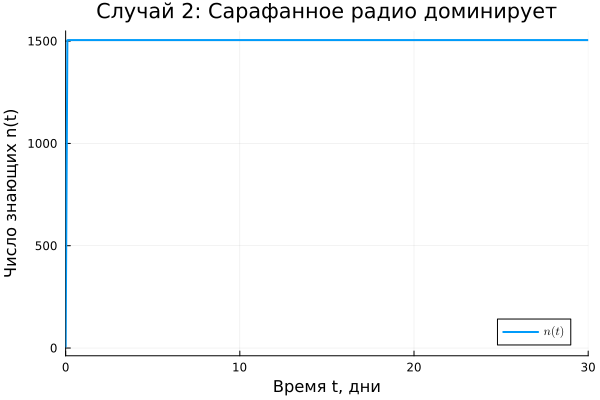

In [6]:
max_idx = argmax(dn2)
t_max = t_vals[max_idx]
v_max = dn2[max_idx]
println("   📊 Максимальная скорость распространения:")
println("      t_max = $(round(t_max, digits=2)) дней")
println("      v_max = $(round(v_max, digits=2)) чел/день")

p2 = plot(sol2, idxs=1, label=L"n(t)", linewidth=2,
          xlabel="Время t, дни", ylabel="Число знающих n(t)",
          title="Случай 2: Сарафанное радио доминирует")

## 6. Сравнение эффективности рекламы

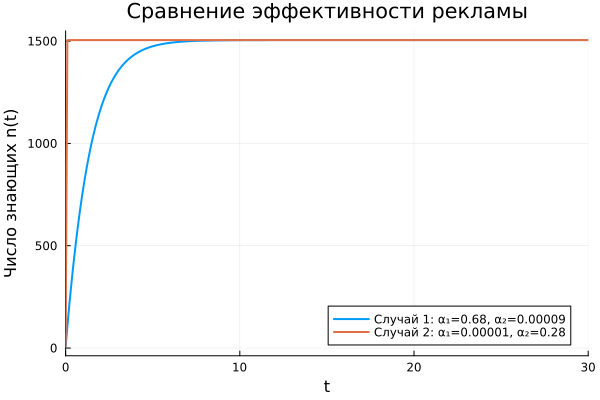

In [7]:
p_compare = plot(title="Сравнение эффективности рекламы",
                 xlabel="Время t, дни", ylabel="Число знающих n(t)",
                 legend=:bottomright)
plot!(p_compare, sol1, idxs=1, label="Случай 1: α₁=0.68, α₂=0.00009", linewidth=2)
plot!(p_compare, sol2, idxs=1, label="Случай 2: α₁=0.00001, α₂=0.28", linewidth=2)

## 7. Скорость распространения рекламы

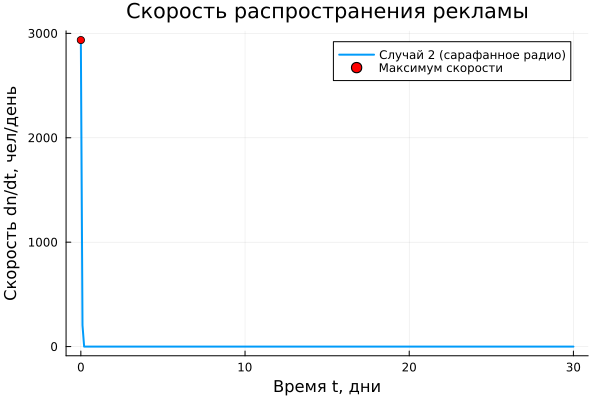

In [8]:
p_velocity = plot(title="Скорость распространения рекламы",
                  xlabel="Время t, дни", ylabel="Скорость dn/dt, чел/день",
                  legend=:topright)
plot!(p_velocity, t_vals, dn2, label="Случай 2 (сарафанное радио)", linewidth=2)
scatter!(p_velocity, [t_max], [v_max], color=:red, label="Максимум скорости")

## 8. Только платная и только бесплатная реклама

### 8.1. Только платная реклама (α₂ = 0)

In [9]:
function only_paid!(du, u, p, t)
    n = u[1]
    α₁ = 0.68
    α₂ = 0.0
    du[1] = (α₁ + α₂ * n) * (N - n)
    nothing
end

prob_paid = ODEProblem(only_paid!, [n0], tspan)
sol_paid = solve(prob_paid, saveat=0.1)

retcode: Success
Interpolation: 1st order linear
t: 301-element Vector{Float64}:
  0.0
  0.1
  0.2
  0.3
  0.4
  0.5
  0.6
  0.7
  0.8
  0.9
  1.0
  1.1
  1.2
  ⋮
 28.9
 29.0
 29.1
 29.2
 29.3
 29.4
 29.5
 29.6
 29.7
 29.8
 29.9
 30.0
u: 301-element Vector{Vector{Float64}}:
 [7.0]
 [105.47781298931164]
 [197.48174068716565]
 [283.4373820048534]
 [363.7424106714557]
 [438.76806819433995]
 [508.8616471448993]
 [574.3475551516455]
 [635.528157179626]
 [692.6866382095708]
 [746.0877899597599]
 [795.9789944287717]
 [842.5899158772839]
 ⋮
 [1504.9973090422945]
 [1504.9974527453085]
 [1504.9975795547737]
 [1504.997691838688]
 [1504.9977921351203]
 [1504.9978831522105]
 [1504.997967768169]
 [1504.9980490312778]
 [1504.9981301598896]
 [1504.998214542428]
 [1504.998305737388]
 [1504.9984074733345]

### 8.2. Только сарафанное радио (α₁ = 0)

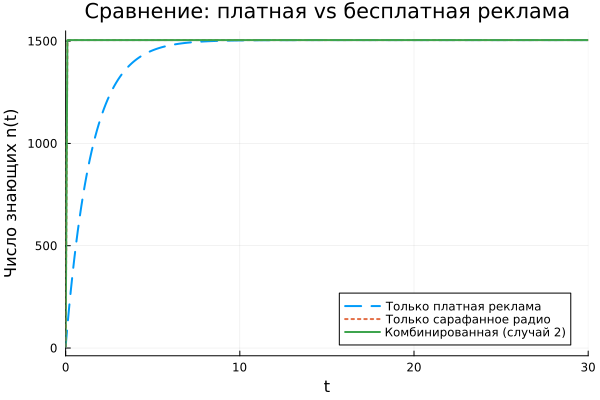

In [10]:
function only_word!(du, u, p, t)
    n = u[1]
    α₁ = 0.0
    α₂ = 0.28
    du[1] = (α₁ + α₂ * n) * (N - n)
    nothing
end

prob_word = ODEProblem(only_word!, [n0], tspan)
sol_word = solve(prob_word, saveat=0.1)

p_compare2 = plot(title="Сравнение: платная vs бесплатная реклама",
                  xlabel="Время t, дни", ylabel="Число знающих n(t)",
                  legend=:bottomright)
plot!(p_compare2, sol_paid, idxs=1, label="Только платная реклама", linewidth=2, linestyle=:dash)
plot!(p_compare2, sol_word, idxs=1, label="Только сарафанное радио", linewidth=2, linestyle=:dot)
plot!(p_compare2, sol2, idxs=1, label="Комбинированная (случай 2)", linewidth=2)

## 9. Сохранение результатов

In [11]:
savefig(p1, plotsdir(script_name, "case1.png"))
savefig(p2, plotsdir(script_name, "case2.png"))
savefig(p_compare, plotsdir(script_name, "comparison.png"))
savefig(p_velocity, plotsdir(script_name, "velocity.png"))
savefig(p_compare2, plotsdir(script_name, "paid_vs_word.png"))

println("\n" * "="^60)
println("✅ ЛАБОРАТОРНАЯ РАБОТА ЗАВЕРШЕНА!")
println("="^60)
println("\n📁 Результаты сохранены в:")
println("  - plots/$(script_name)/case1.png")
println("  - plots/$(script_name)/case2.png")
println("  - plots/$(script_name)/comparison.png")
println("  - plots/$(script_name)/velocity.png")
println("  - plots/$(script_name)/paid_vs_word.png")
println("\n📊 Для случая 2:")
println("  Время максимальной скорости: t = $(round(t_max, digits=2)) дней")


✅ ЛАБОРАТОРНАЯ РАБОТА ЗАВЕРШЕНА!

📁 Результаты сохранены в:
  - plots//case1.png
  - plots//case2.png
  - plots//comparison.png
  - plots//velocity.png
  - plots//paid_vs_word.png

📊 Для случая 2:
  Время максимальной скорости: t = 0.0 дней
